# A one-dimensional Monge map between Gaussian mixtures

**Credit.** This notebook is part of *Optimal Transport for Machine Learners* by [Gabriel Peyré](https://www.gpeyre.com/), CNRS and École normale supérieure, PSL University. The book and reproducible sources are available at [github.com/gpeyre/ot4ml](https://github.com/gpeyre/ot4ml).

**Copyright.** Copyright (c) 2025 Gabriel Peyré. Released under the MIT License; see the repository `LICENSE` file.

This notebook generates `fig:monge-1d-map-mixtures`. It computes the monotone quadratic Monge map from a two-component Gaussian mixture to a three-component Gaussian mixture. The first panel visualizes a dense family of equal-quantile transport rays without empirical atoms; the second displays the graph of the same map with its source and target densities.


In [1]:
# --- OT4ML lightweight Colab bootstrap: one shared core, no repository clone.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import sys as _OT4ML_sys
import urllib.request as _OT4ML_urllib_request

_OT4ML_MPLCONFIG = _OT4ML_Path(
    _OT4ML_os.environ.get(
        "MPLCONFIGDIR",
        _OT4ML_Path(_OT4ML_os.environ.get("TMPDIR", "/tmp")) / "mpl-ot4ml",
    )
)
_OT4ML_MPLCONFIG.mkdir(parents=True, exist_ok=True)
_OT4ML_os.environ["MPLCONFIGDIR"] = str(_OT4ML_MPLCONFIG)


def _ot4ml_find_core():
    """Locate the single shared figure core in a local checkout."""
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        for candidate in (base / "notebooks-figures" / "figure_style.py", base / "figure_style.py"):
            if candidate.exists():
                return candidate
    return None


def _ot4ml_download_core(target):
    """Download only the shared figure core, never the full repository."""
    target.parent.mkdir(parents=True, exist_ok=True)
    urls = (
        "https://raw.githubusercontent.com/gpeyre/ot4ml/main/notebooks-figures/figure_style.py",
        "https://www.gpeyre.com/ot4ml/notebooks-figures/figure_style.py",
    )
    errors = []
    for url in urls:
        try:
            with _OT4ML_urllib_request.urlopen(url, timeout=30) as response:
                target.write_bytes(response.read())
            return target
        except Exception as error:
            errors.append(f"{url}: {error}")
    raise RuntimeError("Unable to download the OT4ML figure core.\n" + "\n".join(errors))


_OT4ML_CORE = _ot4ml_find_core()
if _OT4ML_CORE is None:
    _OT4ML_CORE = _ot4ml_download_core(
        _OT4ML_Path("/content/ot4ml-figure-runtime/notebooks-figures/figure_style.py")
    )

_OT4ML_SPEC = _OT4ML_importlib_util.spec_from_file_location("figure_style", _OT4ML_CORE)
if _OT4ML_SPEC is None or _OT4ML_SPEC.loader is None:
    raise RuntimeError(f"Cannot load OT4ML figure core from {_OT4ML_CORE}")
_OT4ML_STYLE = _OT4ML_importlib_util.module_from_spec(_OT4ML_SPEC)
_OT4ML_sys.modules["figure_style"] = _OT4ML_STYLE
_OT4ML_SPEC.loader.exec_module(_OT4ML_STYLE)

_OT4ML_PACKAGES = (
    ('numpy', 'numpy'),
    ('matplotlib', 'matplotlib'),
    ('scipy', 'scipy'),
)
_OT4ML_REQUIRED_FILES = (

)
ROOT = _OT4ML_STYLE.configure_notebook(
    packages=_OT4ML_PACKAGES,
    required_files=_OT4ML_REQUIRED_FILES,
)
FIGROOT = ROOT / "notebooks-figures"
NOTEBOOK_DIR = FIGROOT


In [2]:
from pathlib import Path
import logging

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

from figure_style import (
    BACKGROUND,
    BLUE,
    RED,
    VIOLET,
    box_axes,
    figure_dir,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()
logging.getLogger("fontTools").setLevel(logging.ERROR)

NAME = "monge-1d-map-mixtures"
OUT = figure_dir(NAME)
THUMB = ROOT / "notebooks-figures" / "thumbnails" / f"{NAME}.png"
THUMB.parent.mkdir(parents=True, exist_ok=True)


## Monotone rearrangement

For atomless probability measures on the line, the quadratic Monge map is

$$
T=\mathcal C_\beta^{-1}\circ\mathcal C_\alpha,
\qquad T_\#\alpha=\beta.
$$

Equivalently, each quantile level $r\in(0,1)$ connects $\mathcal C_\alpha^{-1}(r)$ to $\mathcal C_\beta^{-1}(r)$. We discretize only the one-dimensional integrals used to evaluate these cumulative and quantile functions; the input laws remain continuous Gaussian mixtures.


In [3]:
GRID = np.linspace(-3.6, 3.6, 8000)
SOURCE_PARAMETERS = {
    "weights": np.array([0.46, 0.54]),
    "means": np.array([-1.45, 0.78]),
    "scales": np.array([0.34, 0.43]),
}
TARGET_PARAMETERS = {
    "weights": np.array([0.24, 0.43, 0.33]),
    "means": np.array([-2.02, 0.05, 1.92]),
    "scales": np.array([0.24, 0.39, 0.28]),
}


def gaussian_mixture_density(x, weights, means, scales):
    """Evaluate a normalized one-dimensional Gaussian-mixture density.

    Args:
        x: One-dimensional evaluation grid.
        weights: Nonnegative component weights summing to one.
        means: Component means.
        scales: Strictly positive component standard deviations.

    Returns:
        Density values normalized by trapezoidal quadrature on ``x``.
    """
    x = np.asarray(x, dtype=float)
    density = np.zeros_like(x)
    for weight, mean, scale in zip(weights, means, scales):
        standardized = (x - mean) / scale
        density += weight * np.exp(-0.5 * standardized**2) / (scale * np.sqrt(2.0 * np.pi))
    return density / np.trapezoid(density, x)


def cdf_from_density(x, density):
    """Integrate a sampled density into a normalized monotone CDF.

    Args:
        x: Strictly increasing one-dimensional grid.
        density: Nonnegative density values sampled on ``x``.

    Returns:
        Cumulative probabilities on the same grid, ranging from zero to one.
    """
    increments = 0.5 * (density[:-1] + density[1:]) * np.diff(x)
    cdf = np.r_[0.0, np.cumsum(increments)]
    cdf /= cdf[-1]
    return np.maximum.accumulate(cdf)


def quantile_from_cdf(x, cdf, levels):
    """Evaluate generalized quantiles by monotone interpolation.

    Args:
        x: Grid supporting the cumulative distribution values.
        cdf: Monotone cumulative probabilities on ``x``.
        levels: Quantile levels in the open unit interval.

    Returns:
        Locations of the requested quantiles.
    """
    return np.interp(levels, cdf, x)


source_density = gaussian_mixture_density(GRID, **SOURCE_PARAMETERS)
target_density = gaussian_mixture_density(GRID, **TARGET_PARAMETERS)
source_cdf = cdf_from_density(GRID, source_density)
target_cdf = cdf_from_density(GRID, target_density)

# Dense levels render the continuous quantile correspondence without empirical atoms.
RAY_LEVELS = np.linspace(0.003, 0.997, 140)
source_quantiles = quantile_from_cdf(GRID, source_cdf, RAY_LEVELS)
target_quantiles = quantile_from_cdf(GRID, target_cdf, RAY_LEVELS)

# Evaluate T(x)=C_beta^{-1}(C_alpha(x)) where the source carries visible mass.
map_values = quantile_from_cdf(
    GRID,
    target_cdf,
    np.clip(source_cdf, 1.0e-7, 1.0 - 1.0e-7),
)
map_mask = source_density >= 2.5e-3 * source_density.max()

# Check both the displayed quantiles and the map identity on the visible source support.
transported_levels = np.interp(target_quantiles, GRID, target_cdf)
map_cdf_residual = np.interp(map_values[map_mask], GRID, target_cdf) - source_cdf[map_mask]
print(f"Maximum quantile residual: {np.max(np.abs(transported_levels - RAY_LEVELS)):.2e}")
print(f"Maximum visible push-forward residual: {np.max(np.abs(map_cdf_residual)):.2e}")
print(f"Minimum visible map increment: {np.min(np.diff(map_values[map_mask])):.2e}")


Maximum quantile residual: 1.11e-16
Maximum visible push-forward residual: 1.11e-16
Minimum visible map increment: 3.17e-05


## Two views of the same map

The transport-ray panel emphasizes mass correspondence: every thin segment carries an equal infinitesimal quantile interval. The graph panel instead treats $T$ as a function, with the source density glued above the horizontal axis and the target density glued to the right of the vertical axis.


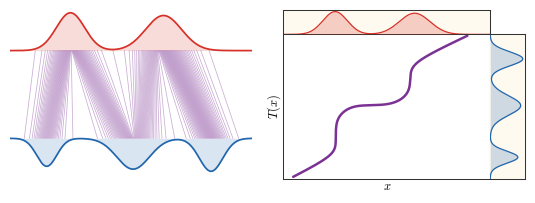

In [4]:
DISPLAY_LIMITS = (-2.9, 2.9)
XLIM = DISPLAY_LIMITS
YLIM = DISPLAY_LIMITS


def draw_quantile_rays(ax):
    """Draw continuous source/target densities and dense equal-quantile rays.

    Args:
        ax: Matplotlib axes receiving the transport-ray display.

    Returns:
        None. The axes are modified in place.
    """
    source_base = 0.79
    target_base = 0.21
    density_scale = 0.25 / max(source_density.max(), target_density.max())

    ax.fill_between(
        GRID,
        source_base,
        source_base + density_scale * source_density,
        color=RED,
        alpha=0.17,
        linewidth=0,
    )
    ax.plot(GRID, source_base + density_scale * source_density, color=RED, lw=1.25)
    ax.fill_between(
        GRID,
        target_base,
        target_base - density_scale * target_density,
        color=BLUE,
        alpha=0.17,
        linewidth=0,
    )
    ax.plot(GRID, target_base - density_scale * target_density, color=BLUE, lw=1.25)

    for level, source_x, target_y in zip(RAY_LEVELS, source_quantiles, target_quantiles):
        ax.plot(
            [source_x, target_y],
            [source_base, target_base],
            color=VIOLET,
            lw=0.55,
            alpha=0.40,
            zorder=1,
        )

    ax.set_xlim(*XLIM)
    ax.set_ylim(-0.06, 1.06)
    remove_axes(ax)


def draw_map_graph(fig, outer_spec):
    """Draw the monotone map with source and target marginal densities.

    Args:
        fig: Matplotlib figure receiving the nested axes.
        outer_spec: GridSpec slot occupied by the complete panel.

    Returns:
        None. Three aligned axes are added to ``fig``.
    """
    ax_map = fig.add_subplot(outer_spec)
    divider = make_axes_locatable(ax_map)
    # Append the marginals directly to the map axes so all shared boundaries align.
    ax_top = divider.append_axes("top", size="17%", pad=0.0, sharex=ax_map)
    ax_right = divider.append_axes("right", size="17%", pad=0.0, sharey=ax_map)

    ax_map.plot(
        GRID[map_mask],
        map_values[map_mask],
        color=VIOLET,
        lw=1.8,
        solid_capstyle="round",
    )
    ax_map.set_xlim(*XLIM)
    ax_map.set_ylim(*YLIM)
    ax_map.set_aspect("auto")
    ax_map.set_xlabel(r"$x$", labelpad=0.6)
    ax_map.set_ylabel(r"$T(x)$", labelpad=0.6)
    ax_map.tick_params(labelbottom=False, labelleft=False, length=0)
    ax_map.set_facecolor("white")
    box_axes(ax_map)

    visible_source = (GRID >= XLIM[0]) & (GRID <= XLIM[1])
    ax_top.fill_between(GRID, 0.0, source_density, color=RED, alpha=0.22, linewidth=0)
    ax_top.plot(GRID, source_density, color=RED, lw=0.9)
    ax_top.set_xlim(*XLIM)
    ax_top.set_ylim(0.0, 1.08 * source_density[visible_source].max())
    ax_top.tick_params(labelbottom=False, labelleft=False, length=0)
    ax_top.set_facecolor(BACKGROUND)
    box_axes(ax_top)
    # The map's top spine is the shared boundary of the two tightly attached boxes.
    ax_top.spines["bottom"].set_visible(False)

    visible_target = (GRID >= YLIM[0]) & (GRID <= YLIM[1])
    ax_right.fill_betweenx(GRID, 0.0, target_density, color=BLUE, alpha=0.22, linewidth=0)
    ax_right.plot(target_density, GRID, color=BLUE, lw=0.9)
    ax_right.set_ylim(*YLIM)
    ax_right.set_xlim(0.0, 1.08 * target_density[visible_target].max())
    ax_right.tick_params(labelbottom=False, labelleft=False, length=0)
    ax_right.set_facecolor(BACKGROUND)
    box_axes(ax_right)
    # Likewise, the map's right spine supplies the shared vertical boundary.
    ax_right.spines["left"].set_visible(False)


figure, axis = plt.subplots(figsize=(3.35, 2.05))
draw_quantile_rays(axis)
save_pdf(figure, OUT / "quantile-rays.pdf", pad_inches=0.025)
plt.close(figure)

figure = plt.figure(figsize=(3.438, 2.05))
outer = figure.add_gridspec(1, 1)
draw_map_graph(figure, outer[0])
save_pdf(figure, OUT / "map-graph.pdf", pad_inches=0.025)
plt.close(figure)

# The gallery thumbnail reproduces the two-panel layout of the book figure.
figure = plt.figure(figsize=(6.65, 2.2))
outer = figure.add_gridspec(1, 2, width_ratios=[1.0, 1.0], wspace=0.13)
axis = figure.add_subplot(outer[0])
draw_quantile_rays(axis)
draw_map_graph(figure, outer[1])
figure.savefig(THUMB, dpi=220, bbox_inches="tight", pad_inches=0.025)
plt.show()
